# Photophysics of Carborhodamines in H2O

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import matplotlib.pyplot as plt
import src.formulas as fo

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
fluorophore = fl.Fluorophore(name='atto643', position=[0, 0])

C:\Users\SagixOffice\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\fluorophores.py:43: UserWarning: Fluorophore atto643 not known. Parameters have to be defined manually.
  warnings.warn(f'Fluorophore {self.name} not known. Parameters have to be defined manually.')


In [3]:
fluorophore_system = fl.FluorophoreSystem([fluorophore])

## constants

In [4]:
fluorescence_lifetime = 3e-9
triplet_lifetime = 5e-6
triplet_yield = 0.02
fluorescence_yield = 0.6
internal_conversion_yield = 0.2
extinction_coeff = 1.5e5

wavelength = 644
irradiance = 2.5 
frame = '5ms'
photon_collection_rate = 0.01

Assumes internal conversion yield to be 0.2

In [5]:
wavenumber, wavelength, frequency = fo.convert_wavenumber_wavelength_frequency(wavelength=wavelength)
photon_flux = fo.calculate_photon_flux(irradiance=irradiance, frequency=frequency)
excitation_rate = fo.calculate_excitation_rate(photon_flux=photon_flux, extinction_coefficient=extinction_coeff)
emission_rate = fo.calculate_emission_rate(quantum_yield=fluorescence_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_st_rate = fo.calculate_emission_rate(quantum_yield=triplet_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_ts_rate = 1/triplet_lifetime
internal_conversion_rate = fo.calculate_emission_rate(quantum_yield=internal_conversion_yield, fluorescence_lifetime=fluorescence_lifetime)

In [39]:
excitation = tr.Transition(tr.TransitionType.EXCITATION, excitation_rate)
emission = tr.Transition(tr.TransitionType.FLUORESCENT_EMISSION, emission_rate)
isc_st = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_ST, isc_st_rate)
isc_ts = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_TS, isc_ts_rate)
internal_conversion = tr.Transition(tr.TransitionType.INTERNAL_CONVERSION_S, internal_conversion_rate)
h2o_attack = tr.Transition(tr.TransitionType.H2O_ATTACK, 3e4)
back_reaction = tr.Transition(tr.TransitionType.BACK_REACTION, 1e-1)

transitions = [excitation, emission, internal_conversion, isc_st, isc_ts, h2o_attack, back_reaction]

In [40]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [41]:
transition_set.finalize()

<AxesSubplot:>

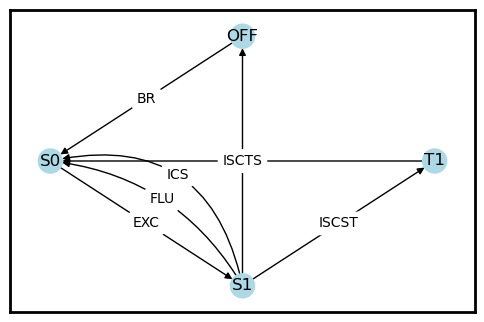

In [42]:
transition_set.plot()

In [43]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,4.648418e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.000000e+08,True,False,None
2,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,6.666667e+07,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,6.666667e+06,False,False,None
4,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,2.000000e+05,False,False,None
5,TransitionType.H2O_ATTACK,H2O,SingleState.S1,SingleState.OFF,3.000000e+04,False,False,None
6,TransitionType.BACK_REACTION,BR,SingleState.OFF,SingleState.S0,1.000000e-01,False,False,None


In [44]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=None, use_memmap=None, seed=3)

In [45]:
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=frame, emccd_gain=10, 
                         seed=100)

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

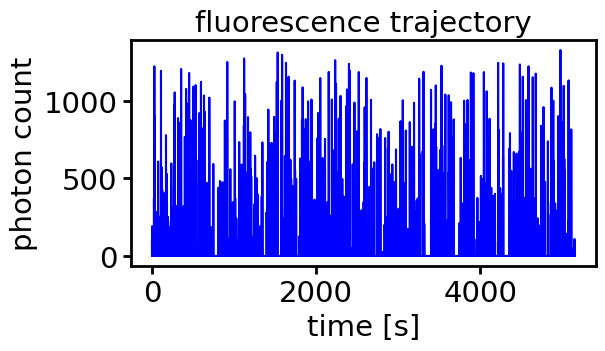

In [46]:
emissions.plot(mode='time_series')

In [47]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-7, exp_max=1)

array([[<AxesSubplot:title={'center':'$\\tau_{min} = 1.39e-07$ s'}, xlabel='$\\tau \\ [s]$', ylabel='$G(\\tau)$'>]],
      dtype=object)

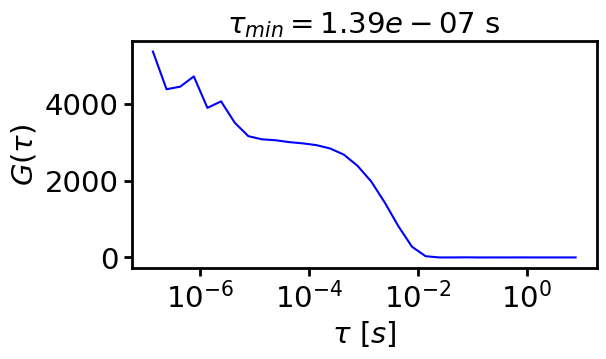

In [48]:
fcs.plot()

In [49]:
blinking = bl.Blinking(emissions)

array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

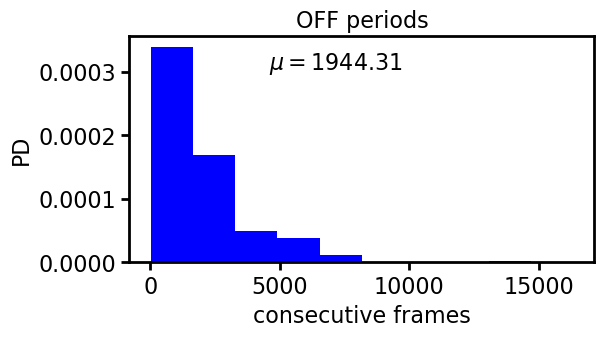

In [50]:
blinking.plot(mode='off_histogram')

array([[<AxesSubplot:title={'center':'ON periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

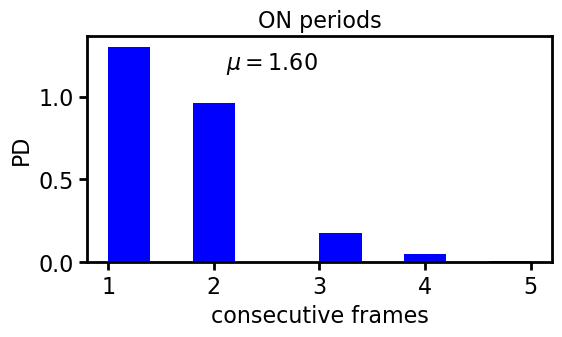

In [51]:
blinking.plot(mode='on_histogram')